# Event-data-driven GRB localization with a regular HEALPix score map and an INR
## GRB bn081207680 (COSI DC4)

End-to-end Method-1 workflow, regular full-sky HEALPix only (no multi-resolution/MOC):

$$\text{on-burst events}\ \rightarrow\ \text{exact localization score }S(l,b)\ \text{on a
full-sky HEALPix grid (parallel)}\ \rightarrow\ \texttt{Score\_Map.fits}\ \rightarrow\
\text{INR surrogate}\ \rightarrow\ (l_{\rm INR},b_{\rm INR})\ \rightarrow\
\Delta S\le4.605\ \text{region}\ \rightarrow\ \text{convex hull}\ \rightarrow\
\text{spherical ellipse}$$

The statistic is the **localization score**
$$S(\mathbf s)=2[\ell(\mathbf s)-\ell_0],\qquad
\Delta S(\mathbf s)=S_{\max}-S(\mathbf s),$$
built from the per-event Compton-cone geometry (Section 4).  $\ell$ is a profile
quasi-likelihood, so $S$ is used for localization only; the nominal 90% region
$\boxed{\Delta S\le 4.605}$ uses the $\chi^2_{2,0.90}$ reference value, mirroring the
COSI TS-map region workflow.  All heavy computation lives in the `inr_angular` package;
this notebook orchestrates and visualizes.  The true source position appears only in
Section 15, after everything is final.

## 1. Imports and configuration

Local-kernel stability: the parallel numba engine is only used after a
throwaway subprocess has survived the same kind of parallel launch on this
machine (a native crash there cannot touch this kernel); otherwise the scan
automatically uses the serial numba kernel with identical results.  The
scoring phase is torch-free (torch loads only at the INR stage).  To force an
engine, set `INR_ANGULAR_ENGINE` to `"parallel"`, `"serial"`, or `"numpy"`
before creating the scorer.  If this notebook has ever crashed the kernel,
run `ia.run_environment_check()` in a fresh kernel: it tests every fragile
component in disposable subprocesses and names the one that fails.


In [1]:
import os
import time
import numpy as np
import healpy as hp
import scipy.stats
import matplotlib.pyplot as plt
from pathlib import Path

from astropy.coordinates import SkyCoord
import astropy.units as u
from mhealpy import HealpixMap

import inr_angular as ia

%matplotlib inline

GRB_name = "GRB_bn081207680"
raw_signal_file_name = "GRB_bn081207680_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
background_file_stem = "Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck"

# GRB interval; the on-burst selection is the mandated zero-padding window
GRB_start_time_unbinned = 1836496300.0
GRB_end_time_unbinned   = 1836496388.9730453
GRB_start_time = np.floor(GRB_start_time_unbinned)
GRB_end_time   = np.ceil(GRB_end_time_unbinned)
data_start_time = GRB_start_time - 0
data_end_time   = GRB_end_time + 0

NSIDE = 256          # the nominal region is drawn on this grid, so the grid must
                     # resolve it; 256 (0.23 deg pixels) resolves both the sharp
                     # regions of bright bursts and the broader regions of fainter
                     # ones with plenty of hull vertices for the ellipse fit
N_WORKERS = None     # None = all available CPU cores; set an int to restrict
SEED = ia.SEED
cfg = ia.Method1Config()

output_dir = Path("Results") / GRB_name
output_dir.mkdir(parents=True, exist_ok=True)
print(f"NSIDE = {NSIDE} | workers = {N_WORKERS or os.cpu_count()} | seed = {SEED}")

NSIDE = 256 | workers = 2 | seed = 12345


In [2]:
# optional: pinpoint any environment problem without risking this kernel
# ia.run_environment_check()

## 2. Load GRB angular events

Only the on-burst angular triplets $(\phi_i, l_{{\rm axis},i}, b_{{\rm axis},i})$ enter
the analysis (Galactic coordinates; events with $t_i\in[t_{\rm start},t_{\rm end}]$).
No off-burst data, no instrument response, no effective area, no truth.  The ARM kernel
$h(r|\phi)$ scale is selected once by truth-free cross-validation on these same events.

In [3]:
search_dirs = ["..", "../Data", ".", "./Data"]
signal_path = ia.find_data_file(raw_signal_file_name, search_dirs)
background_path = ia.find_data_file(background_file_stem + ".fits.gz", search_dirs)
if background_path is None:
    background_path = ia.find_background_cache(search_dirs, background_file_stem,
                                               data_start_time, data_end_time)
events = ia.load_onburst_events([signal_path, background_path],
                                data_start_time, data_end_time)
print(f"on-burst events: N = {len(events)}")
print(f"  phi    in [{events.phi_deg.min():.2f}, {events.phi_deg.max():.2f}] deg")
print(f"  l_axis in [{events.l_axis_deg.min():.2f}, {events.l_axis_deg.max():.2f}] deg")
print(f"  b_axis in [{events.b_axis_deg.min():.2f}, {events.b_axis_deg.max():.2f}] deg")

factory = lambda kern: ia.LocalizationScore(events, kern, cfg.objective)
kernel_cfg, _ = ia.select_scale_cv(events, cfg.kernel, factory, seed=SEED, verbose=False)
kernel = ia.ARMKernel.from_config(kernel_cfg)
print(f"ARM kernel: sigma = {kernel_cfg.sigma_deg:.2f} deg (truth-free on-burst CV), "
      f"w_t = {kernel_cfg.tail_weight}, gamma = {np.degrees(kernel.gamma_rad):.2f} deg")

on-burst events: N = 420
  phi    in [9.53, 174.60] deg
  l_axis in [0.24, 359.85] deg
  b_axis in [-83.32, 83.16] deg


ARM kernel: sigma = 6.00 deg (truth-free on-burst CV), w_t = 0.15, gamma = 18.00 deg


## 3. HEALPix configuration

Full-sky grid, `NESTED` ordering, Galactic coordinates: $N_{\rm pix}=12N_{\rm side}^2$
equal-area pixels; each center $(l_p,b_p)$ is one candidate source direction.

In [4]:
N_pix = hp.nside2npix(NSIDE)
print(f"N_pix = 12 x {NSIDE}^2 = {N_pix:,} pixels | "
      f"pixel scale ~ {np.degrees(hp.nside2resol(NSIDE)):.3f} deg | "
      f"scheme = NESTED | coordsys = G")

N_pix = 12 x 256^2 = 786,432 pixels | pixel scale ~ 0.229 deg | scheme = NESTED | coordsys = G


## 4. Compute full-sky localization scores in parallel

For every candidate $\mathbf s=(l,b)$ and every event:
$$\alpha_i=\operatorname{Sep}(\mathbf s,\mathbf a_i),\qquad r_i=\alpha_i-\phi_i,\qquad
g_i=\frac{h(r_i|\phi_i)}{2\pi\sin\alpha_i},$$
$$p_i(\mathbf s,\eta)=\eta g_i+(1-\eta)\tfrac1{4\pi},\qquad
\ell(\mathbf s)=\max_{\eta\in[0,1]}\sum_i\log p_i,\qquad
S(\mathbf s)=2[\ell(\mathbf s)-\ell_0],\ \ \ell_0=-N\log 4\pi.$$

Pixels are scored independently, so the scan parallelizes across pixels: worker threads
share the read-only event arrays (prepared once, no per-task copies), each pixel is one
work item, and the output keeps NESTED pixel order.  Thread count does not affect any
value - each pixel's reduction is serial inside its own task - which the consistency
check below asserts (serial vs parallel, bitwise).

In [5]:
scorer = ia.LocalizationScore(events, kernel, cfg.objective, n_workers=N_WORKERS)
_ = scorer.score(np.array([0.0]), np.array([0.0]))      # jit warm-up + self-validation
print(f"fast path vs numpy/astropy reference: "
      f"{scorer.fast_path_max_dev_ts:.2e} score units (PASS)")

dev = ia.verify_parallel_consistency(events, kernel, cfg.objective, n_check=512)
print(f"serial (1 worker) vs parallel scores, 512 directions: max |diff| = {dev:.1e}")

skymap = ia.regular_scan(scorer, NSIDE, n_workers=N_WORKERS)
scores = skymap.to_full_healpix_array()                 # one exact score per pixel
scan_time_s = skymap.meta["elapsed_s"]
print(f"scored {skymap.meta['n_evaluations']:,} pixels in {scan_time_s:.1f} s "
      f"({skymap.meta['n_workers']} workers)")

fast path vs numpy/astropy reference: 1.00e-11 score units (PASS)
serial (1 worker) vs parallel scores, 512 directions: max |diff| = 0.0e+00


[full-sky scan] NSIDE=256: 786,432 pixels (0.229 deg) scored in 11.1 s | engine = numba-parallel, 2 worker(s); S_max = 266.3 at (l, b) = (175.605, -8.989)
scored 786,432 pixels in 11.1 s (2 workers)


## 5. Save the score map

The FITS map stores exactly one **exact** localization score per HEALPix pixel - INR
predictions are never written into it.

In [6]:
m = HealpixMap(data=scores, scheme="NESTED", coordsys="G")
score_map_path = output_dir / f"{GRB_name}_Score_Map.fits"
m.write_map(str(score_map_path), overwrite=True)
print(f"wrote {score_map_path} ({len(scores):,} exact scores)")

wrote Results/GRB_bn081207680/GRB_bn081207680_Score_Map.fits (786,432 exact scores)


## 6. Inspect the full-sky score map and the best HEALPix pixel

best pixel: NESTED index 407993 at (l, b) = (175.6055, -8.9893), S_max = 266.28 | eta_hat = 0.439


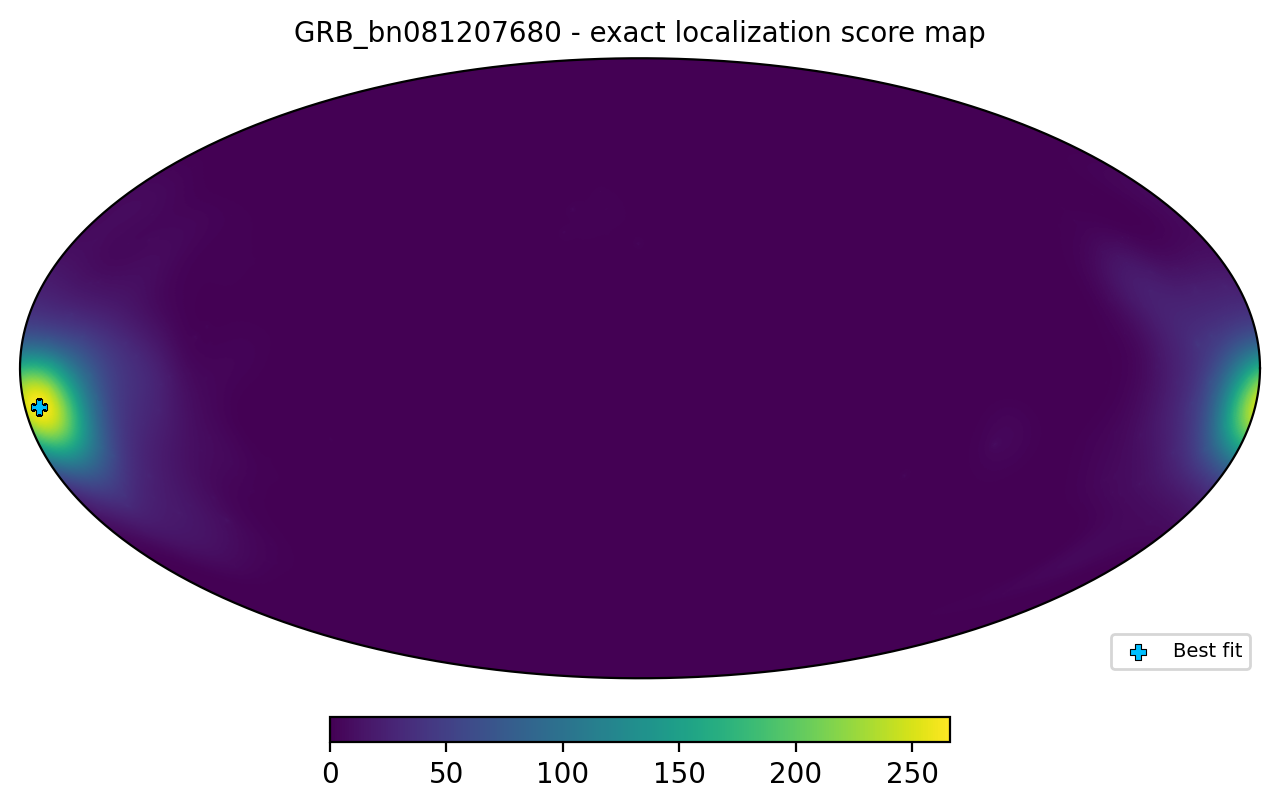

In [7]:
best_pix = int(skymap.ipix[skymap.argmax])
l_pix, b_pix = skymap.best_lb
max_score = skymap.max_score
print(f"best pixel: NESTED index {best_pix} at (l, b) = ({l_pix:.4f}, {b_pix:.4f}), "
      f"S_max = {max_score:.2f} | eta_hat = {skymap.eta[skymap.argmax]:.3f}")

fig = ia.plot_fullsky_map(ia.dense_healpix_map(skymap), GRB_name, best=(l_pix, b_pix),
                          save=output_dir / f"{GRB_name}_Score_Map_fullsky.png")
plt.show()

## 7. Prepare INR training samples

Training inputs are the HEALPix pixel centers, targets are their exact scores - the
same values just written to FITS (asserted).  Positions are embedded as unit vectors
$\mathbf x = (\cos b\cos l,\ \cos b\sin l,\ \sin b)$ with the Method-1 positional
encoding; the network never sees the event arrays.

In [8]:
l_train, b_train, score_train = ia.prepare_training_data(skymap)
assert np.array_equal(score_train, scores[skymap.ipix]), \
    "INR targets must be exactly the saved HEALPix scores"
print(f"training samples: {len(score_train):,} (pixel centers -> exact scores)")

training samples: 786,432 (pixel centers -> exact scores)


## 8. Train and validate the INR

In [9]:
t0 = time.perf_counter()
surrogate = ia.train_inr(l_train, b_train, score_train, cfg=cfg.inr, verbose=False)
print(f"INR trained in {time.perf_counter()-t0:.0f} s | held-out RMSE = "
      f"{surrogate.gate['val_rmse_ts']:.2f} score units | peak-band max|err| = "
      f"{surrogate.gate['val_band_max_abs_ts']:.2f}")
print("the surrogate is used ONLY to obtain (l_INR, b_INR); it never replaces exact "
      "scores and never decides region membership")

INR trained in 16 s | held-out RMSE = 0.34 score units | peak-band max|err| = 1.22
the surrogate is used ONLY to obtain (l_INR, b_INR); it never replaces exact scores and never decides region membership


## 9. INR-refined location $(l_{\rm INR}, b_{\rm INR})$

Continuous local maximization of the trained surrogate around the best HEALPix pixel
(chart ascent; every iterate mapped back to $(l,b)$ before the embedding).  No exact
local refinement follows - $(l_{\rm INR}, b_{\rm INR})$ goes directly into the ellipse
initialization.

In [10]:
l_INR, b_INR, f_INR = surrogate.continuous_argmax(l_pix, b_pix)
print(f"(l_INR, b_INR) = ({l_INR:.4f}, {b_INR:.4f})")

(l_INR, b_INR) = (175.5444, -8.9490)


## 10. Extract the nominal 90% region from the saved score map

Read the FITS back and keep pixels with
$$S \ge S_{\max}-\chi^2_{2,0.90}\quad\Longleftrightarrow\quad \Delta S \le 4.605 .$$
Membership depends only on the exact saved scores.

In [11]:
score_map = HealpixMap.read_map(str(score_map_path))
data = score_map.data
assert len(data) == 12 * NSIDE**2 and np.allclose(data, scores)
assert abs(data.max() - max_score) < 1e-9

critical = scipy.stats.chi2.ppf(0.90, df=2)
region_indices = np.where(data >= data.max() - critical)[0]
region_skycoord = score_map.pix2skycoord(region_indices)
region_score_peak = data[region_indices].max()
print(f"critical = chi2.ppf(0.90, 2) = {critical:.3f}")
print(f"nominal 90% region: {len(region_indices)} pixels with Delta S <= {critical:.3f}")

critical = chi2.ppf(0.90, 2) = 4.605
nominal 90% region: 241 pixels with Delta S <= 4.605


## 11. Convex-hull boundary of the region pixels

In [12]:
edge_pixels, edge_skycoord = ia.hull_boundary(region_skycoord)
print(f"convex hull: {len(edge_pixels)} boundary vertices")

convex hull: 26 boundary vertices


## 12. Fit the spherical ellipse, initialized at $(l_{\rm INR}, b_{\rm INR})$

Same `FitSphericalEllipse` and call style as the TS-map notebook (the vendored copy is
byte-identical to `DC4_GRB_Localization_with_True_BKG/GRB_bn080802386/fit_ellipse.py`);
the only change is the initialization at the INR-refined location instead of the peak
pixel.

In [13]:
fit, ellipse = ia.fit_ellipse_from_hull(edge_skycoord, l_INR, b_INR,
                                        semi_major_init=0.01, semi_minor_init=0.01,
                                        theta_init=45)
center_coord = ellipse["center_coord"]
R90_eq = ellipse["r_eq_deg"]
print(f"R_90,eq = sqrt(a * b) = {R90_eq:.4f} deg")

Fitted Center (l, b): (175.56, -9.04)
Fitted Axes (a, b): (1.91 deg, 1.98 deg)
Fitted Position Angle θ: 28.63 deg
R_90,eq = sqrt(a * b) = 1.9440 deg


## 13. Save the ellipse parameters

In [14]:
ellipse_path = ia.save_ellipse_result_txt(
    output_dir / f"{GRB_name}_Ellipse_result.txt",
    peak_lb=(l_pix, b_pix), inr_lb=(l_INR, b_INR),
    ellipse=ellipse, region_score_peak=region_score_peak)
print(f"wrote {ellipse_path}")
print(open(ellipse_path).read())

wrote Results/GRB_bn081207680/GRB_bn081207680_Ellipse_result.txt
# Peak_l Peak_b INR_l INR_b Center_lon Center_lat Semi_major_axis Semi_minor_axis Equivalent_radius Theta Region_score_peak
175.60546875
-8.98929935
175.54439480
-8.94900599
175.56001137
-9.04084014
1.90830399
1.98037348
1.94400479
28.63451258
266.27627525



## 14. Final localization plot

Style of the COSI TS-map localization figure, score terminology: exact score map
clipped to $[S_{\max}-4.605,\ S_{\max}]$ (so exactly the nominal region lights up),
hull edge points, fitted ellipse and center, score-map peak, INR location; the true
position is drawn for post-hoc evaluation only.

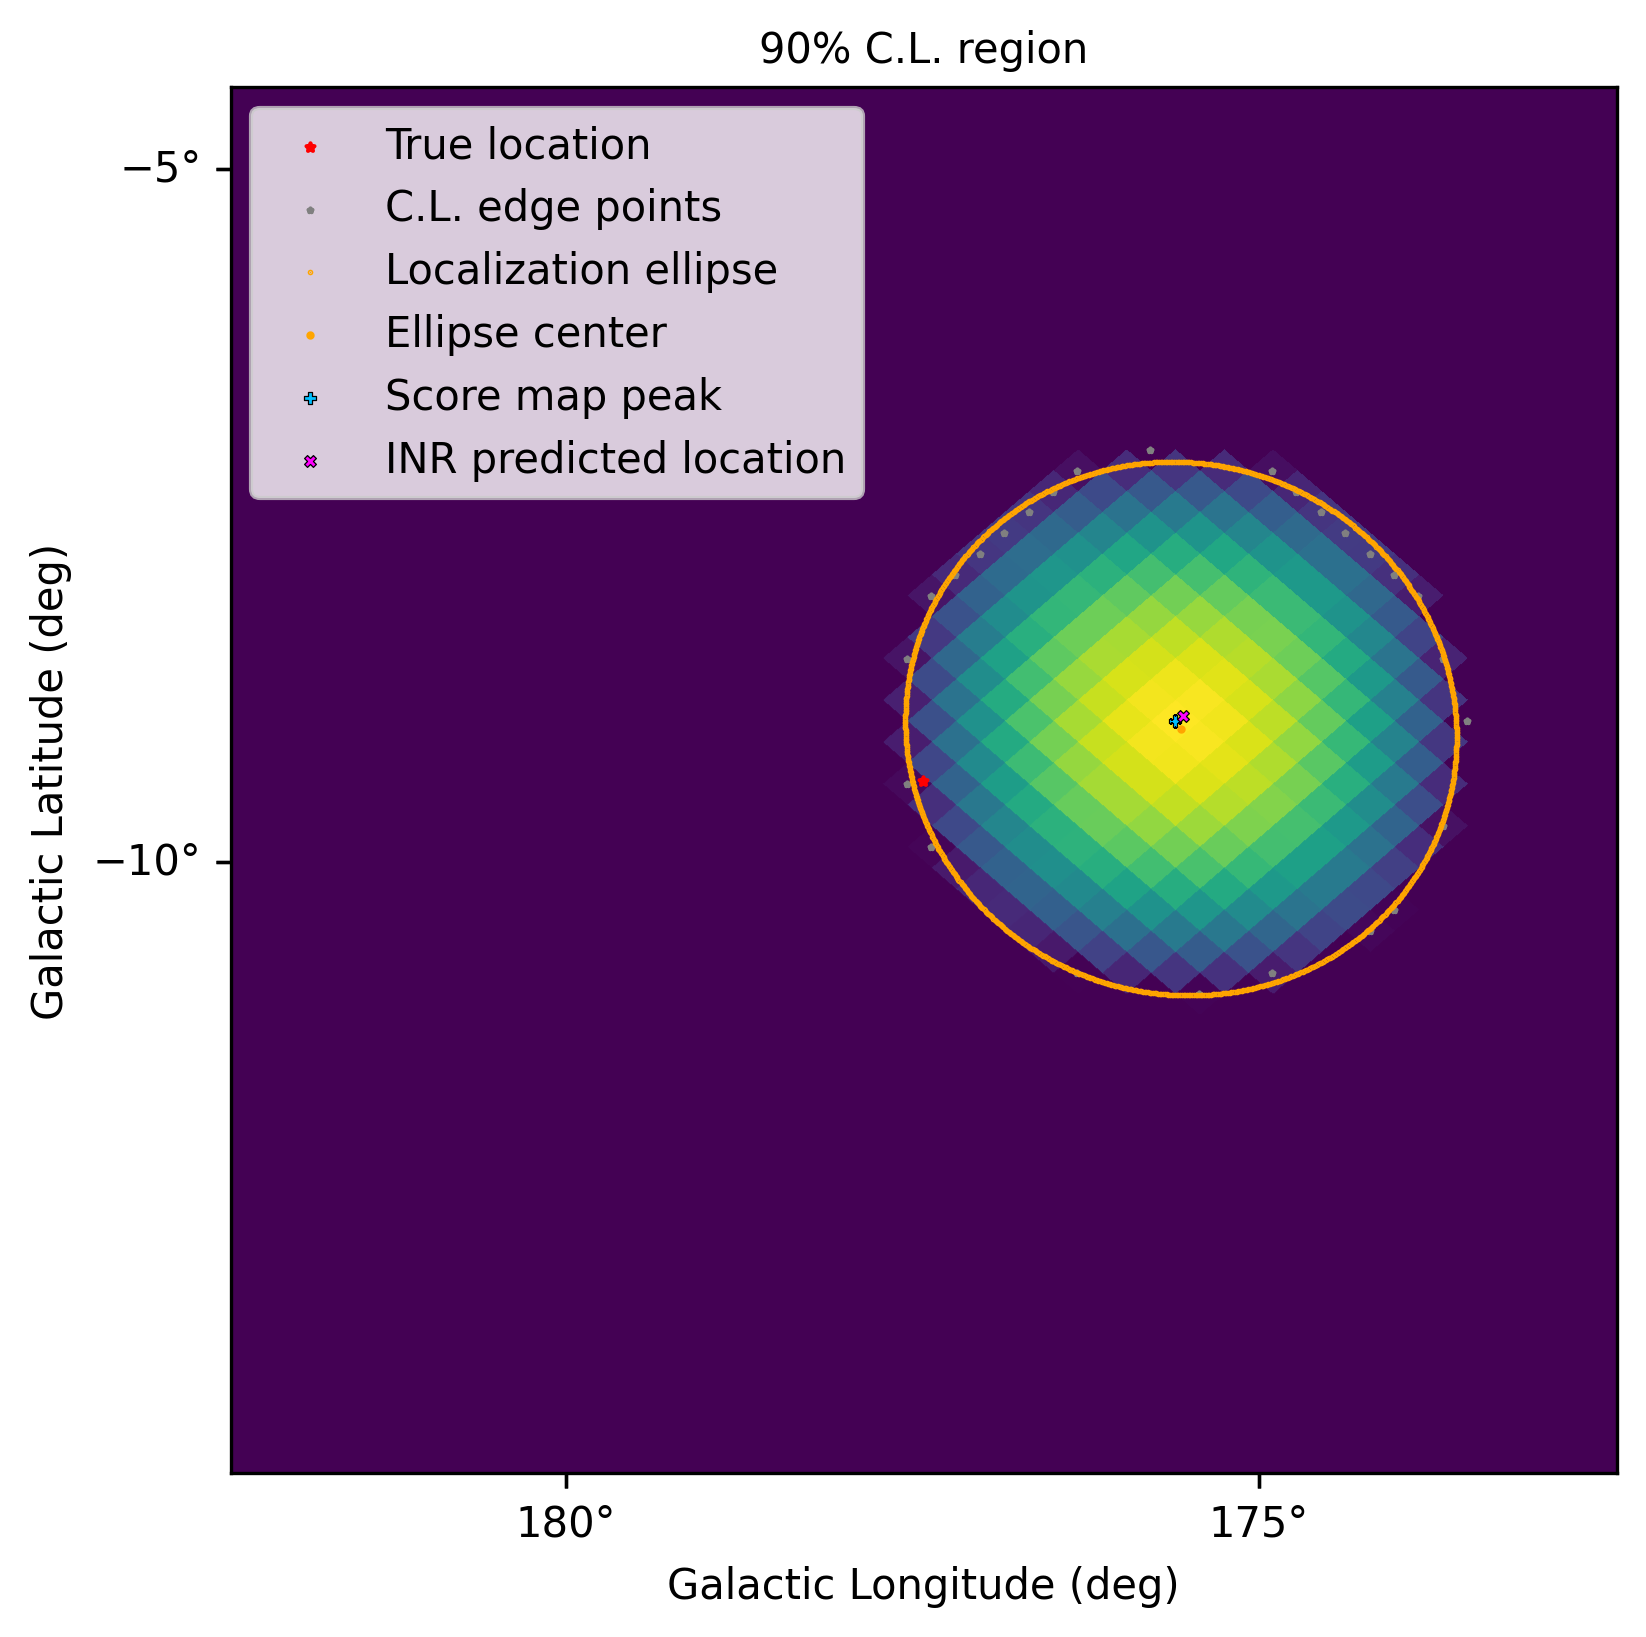

In [15]:
true_l = 177.4207550850385
true_b = -9.416522812322969

ellipse_edge = fit.get_ellipse_edge(npoints=1000)
fig = ia.plot_score_map_with_ellipse(
    score_map, center_window=(true_l, true_b), critical=critical,
    edge_pixels=edge_pixels, ellipse_edge=ellipse_edge, center_coord=center_coord,
    peak=(l_pix, b_pix), inr=(l_INR, b_INR), truth=(true_l, true_b),
    save=output_dir / f"{GRB_name}_Score_Map_with_Ellipse_fitting.png")
plt.show()

## 15. Post-hoc comparison with the true position

The true simulated position enters here for the first time - it was absent from the
score computation, INR training and optimization, region selection, and ellipse fitting.

In [16]:
true_coord = SkyCoord(l=true_l * u.deg, b=true_b * u.deg, frame="galactic")
err_inr = SkyCoord(l=l_INR*u.deg, b=b_INR*u.deg, frame="galactic").separation(true_coord).deg
err_center = center_coord.separation(true_coord).deg
err_pix = SkyCoord(l=l_pix*u.deg, b=b_pix*u.deg, frame="galactic").separation(true_coord).deg

delta_score_truth = float(data.max() - scorer.score_scalar(true_l, true_b))
truth_inside = delta_score_truth <= critical

print(f"{GRB_name} - regular HEALPix localization score + INR")
print(f"  NSIDE / pixels / workers : {NSIDE} / {N_pix:,} / {skymap.meta['n_workers']}")
print(f"  full-sky scoring runtime : {scan_time_s:.1f} s")
print(f"  best pixel               : ({l_pix:.4f}, {b_pix:.4f}), S_max = {max_score:.2f} "
      f"[err {err_pix:.4f} deg]")
print(f"  (l_INR, b_INR)           : ({l_INR:.4f}, {b_INR:.4f}) [err {err_inr:.4f} deg]")
print(f"  ellipse center           : ({center_coord.l.deg:.4f}, {center_coord.b.deg:.4f}) "
      f"[err {err_center:.4f} deg]")
print(f"  a_90, b_90, R_90,eq      : {ellipse['semi_major_deg']:.4f}, "
      f"{ellipse['semi_minor_deg']:.4f}, {R90_eq:.4f} deg | "
      f"PA = {ellipse['theta_deg']:.2f} deg")
print(f"  region peak score        : {region_score_peak:.2f}")
print(f"  Delta S at truth         : {delta_score_truth:.2f} -> inside nominal 90% "
      f"region: {truth_inside}")

GRB_bn081207680 - regular HEALPix localization score + INR
  NSIDE / pixels / workers : 256 / 786,432 / 2
  full-sky scoring runtime : 11.1 s
  best pixel               : (175.6055, -8.9893), S_max = 266.28 [err 1.8421 deg]
  (l_INR, b_INR)           : (175.5444, -8.9490) [err 1.9104 deg]
  ellipse center           : (175.5600, -9.0408) [err 1.8747 deg]
  a_90, b_90, R_90,eq      : 1.9083, 1.9804, 1.9440 deg | PA = 28.63 deg
  region peak score        : 266.28
  Delta S at truth         : 3.97 -> inside nominal 90% region: True
